In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("Hotel Reservations.csv")

# Number of rows
print("Number of rows:", df.shape[0])

# Display first 5 rows
df.head()

Number of rows: 36275


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
# Drop column
df = df.drop(columns=["Booking_ID"])

# Remove rows where no of adults < 1
df = df[df["no_of_adults"] >= 1]

print("New shape:", df.shape)

New shape: (36136, 18)


In [5]:
df["booking status"] = df["booking_status"].map({
    "Not_Canceled": 0,
    "Canceled": 1
})

cancel_percentage = df["booking status"].mean() * 100

print("Percentage canceled:", cancel_percentage)

Percentage canceled: 32.76787690945318


In [6]:
busiest_month = df["arrival_month"].value_counts().idxmax()

print("Busiest month:", busiest_month)

Busiest month: 10


In [7]:
# Create total nights column
df["total_nights"] = (
    df["no_of_weekend_nights"] +
    df["no_of_week_nights"]
)

# Solo travelers
solo_avg = df[df["no_of_adults"] == 1]["total_nights"].mean()

# Families
family_avg = df[df["no_of_adults"] > 1]["total_nights"].mean()

print("Solo average nights:", solo_avg)
print("Family average nights:", family_avg)

Solo average nights: 2.5324236517218974
Family average nights: 3.144122921134981


In [21]:
import pandas as pd

# Load dataset
df = pd.read_csv("Hotel Reservations.csv")

In [22]:
print(df["booking_status"].unique())

['Not_Canceled' 'Canceled']


In [23]:
df["booking_status"] = df["booking_status"].map({
    "Not_Canceled": 0,
    "Canceled": 1
})

In [24]:
print(df["booking_status"].unique())

[0 1]


In [25]:
cancellation_by_segment = (
    df.groupby("market_segment_type")["booking_status"]
    .mean() * 100
)

print(cancellation_by_segment)

market_segment_type
Aviation         29.600000
Complementary     0.000000
Corporate        10.907288
Offline          29.948708
Online           36.508142
Name: booking_status, dtype: float64


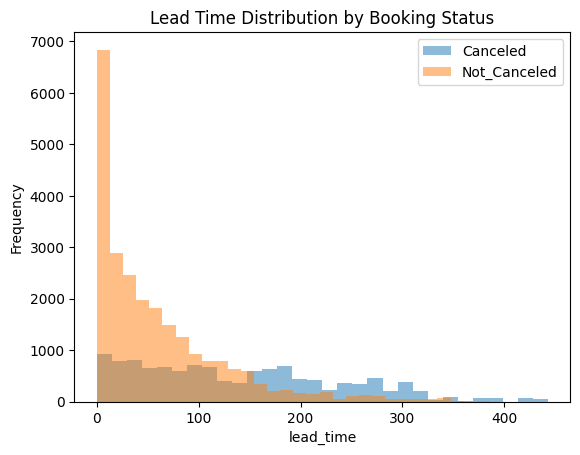

In [27]:
import matplotlib.pyplot as plt

# Separate data
canceled = df[df["booking_status"] == 1]
not_canceled = df[df["booking_status"] == 0]

# Plot histogram
plt.hist(
    canceled["lead_time"],
    bins=30,
    alpha=0.5,
    label="Canceled"
)

plt.hist(
    not_canceled["lead_time"],
    bins=30,
    alpha=0.5,
    label="Not_Canceled"
)

plt.xlabel("lead_time")
plt.ylabel("Frequency")
plt.title("Lead Time Distribution by Booking Status")
plt.legend()

plt.show()

In [28]:
# Find categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['Booking_ID', 'type_of_meal_plan', 'room_type_reserved',
       'market_segment_type'],
      dtype='object')


In [29]:
# Apply one-hot encoding
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("New shape after encoding:", df.shape)

New shape after encoding: (36275, 36302)


In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
scaler = MinMaxScaler()

# Normalize all columns
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print(df_scaled.head())

   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0          0.50             0.0              0.142857           0.117647   
1          0.50             0.0              0.285714           0.176471   
2          0.25             0.0              0.285714           0.058824   
3          0.50             0.0              0.000000           0.117647   
4          0.50             0.0              0.142857           0.058824   

   required_car_parking_space  lead_time  arrival_year  arrival_month  \
0                         0.0   0.505643           0.0       0.818182   
1                         0.0   0.011287           1.0       0.909091   
2                         0.0   0.002257           1.0       0.090909   
3                         0.0   0.476298           1.0       0.363636   
4                         0.0   0.108352           1.0       0.272727   

   arrival_date  repeated_guest  ...  room_type_reserved_Room_Type 2  \
0      0.033333             0.0 

In [18]:
import pandas as pd

df = pd.read_csv("Hotel Reservations.csv")

In [19]:
df = df.drop(columns=["Booking_ID"], errors="ignore")

In [20]:
df["booking_status"] = df["booking_status"].map({
    "Not_Canceled": 0,
    "Canceled": 1
})

In [21]:
print(df["booking_status"].unique())

[0 1]


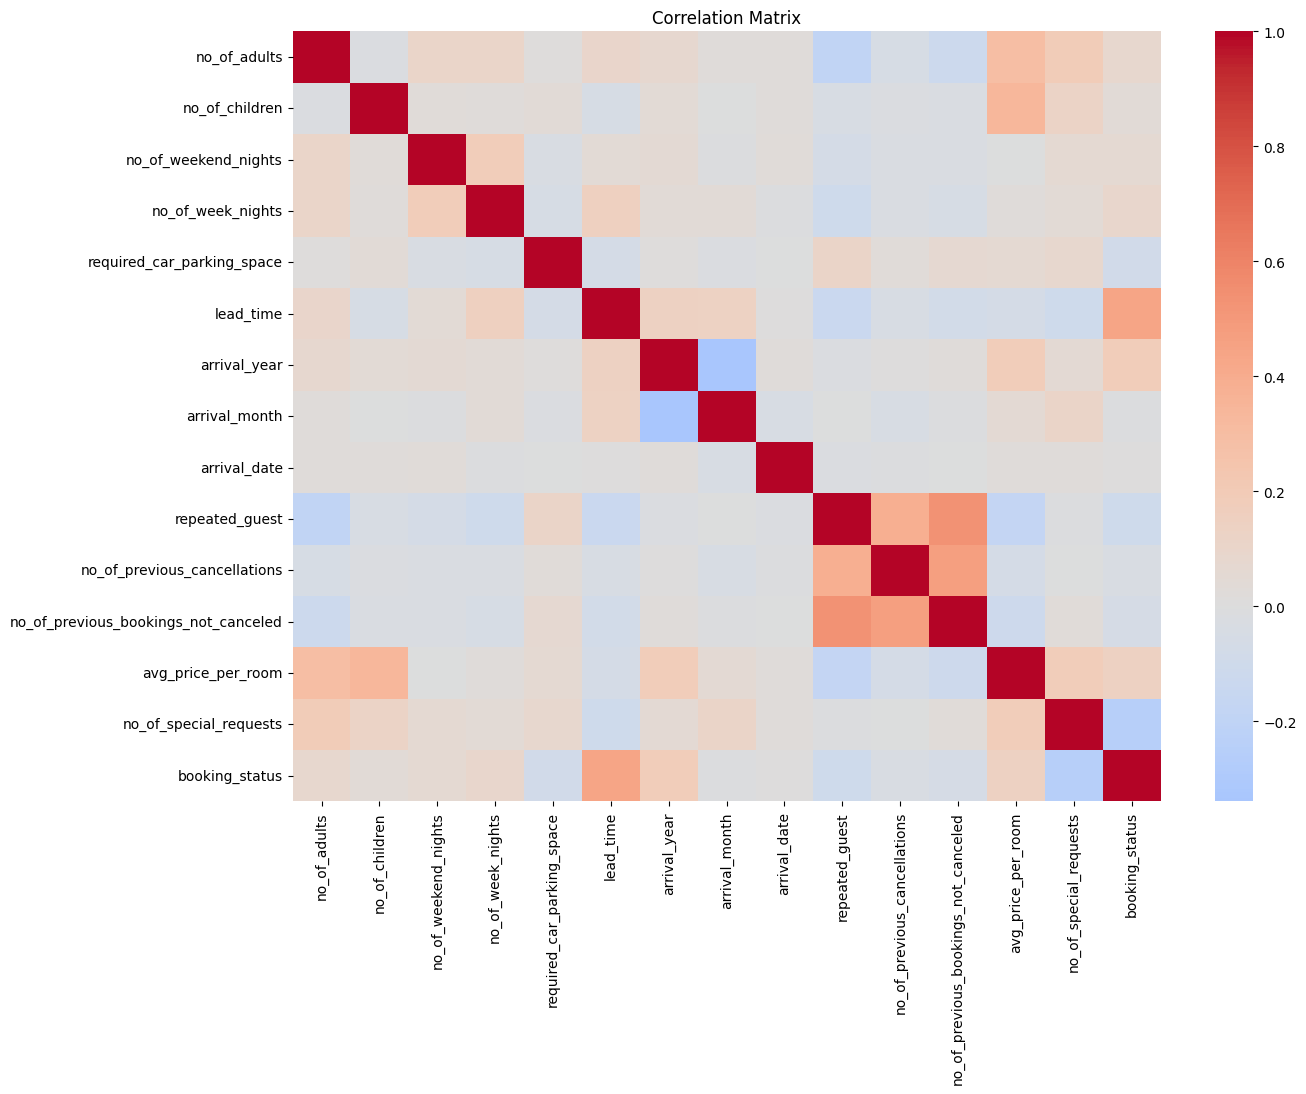

In [22]:
# One-hot encode categorical columns
df = pd.get_dummies(df, drop_first=True)

# Correlation
corr_matrix = df.select_dtypes(include=["number"]).corr()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()